# 08 · Add battery + PV at NZ grid nodes

Change the **input path and site rows** below to study new PV and batteries at
specific existing nodes in the entire NZ grid. Run all cells to solve a baseline
and a battery + PV scenario, compare their results, and download both complete
solutions in one ZIP. Each site row sets PV MW, battery MW, and battery MWh.

This simplified template represents behind-the-meter assets through net demand:

`scenario demand = original demand + battery charge − battery discharge − used PV`

PV availability and battery operation follow a supplied schedule. State of charge,
losses, power limits, and end-of-day energy are checked before the grid solves.
The grid re-optimizes generation, flows, and reserves around these fixed effects.
Battery charging may use grid energy as well as PV. Excess PV is curtailed to
prevent net export; battery discharge that would export is rejected. New assets
are not separate offers, do not provide reserves, and have no optimized charging
or explicit inverter/network-connection model. Use this to assess scheduled
net-demand effects; merchant storage optimization needs a fuller asset model.

Install `"pyspd[gdx]==0.1.0"` in the notebook environment. Supply one complete daily
v5-style NZ grid GDX (46, 48, or 50 half-hour trading periods). The template includes
all cases, including multiple pricing cases in a period. Their shared battery
schedule advances once per trading period, not once per pricing case.


In [1]:
import hashlib
import json
import math
import os
import re
import sys
from dataclasses import replace
from importlib.metadata import version
from importlib.util import find_spec
from pathlib import Path
from uuid import uuid4
from zipfile import ZIP_DEFLATED, ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

from pyspd.application import ApplicationConfiguration, PyspdApplication
from pyspd.data import GdxAdapter, SymbolCatalog
from pyspd.orchestration import (
    DailyCaseDataIndex,
    DailyCasePreparer,
    DailyCaseSelector,
    DailyRunner,
    OverrideApplier,
    OverrideAudit,
    OverrideFamily,
    OverrideInstruction,
    OverrideScope,
)
from pyspd.preprocess.input import CaseInput
from pyspd.reporting import ReportBundle

assert sys.version_info[:2] == (3, 13), "Select a Python 3.13 notebook kernel"
assert version("pyspd") == "0.1.0", "This example targets pyspd==0.1.0"
print({name: version(name) for name in ("pyspd", "highspy", "pyscipopt")})

{'pyspd': '0.1.0', 'highspy': '1.15.1', 'pyscipopt': '5.7.1'}


## Change these lines

Replace the placeholder node with an exact node ID from your input. Add another
site by copying a dictionary row. The default profile charges at full battery power
in TP 21–24 and discharges in TP 37–40 at power adjusted for 95% charging and 95%
discharging efficiency. Batteries start and end empty. PV follows an illustrative
daylight curve, not measured production.

Optionally set `PROFILE_CSV` to your own chronological schedule with columns
`trading_period,duration_hours,pv_capacity_factor,charge_fraction,discharge_fraction`.
Fractions are 0–1; duration is 0.5 hours for each NZ trading period. Use exact period
labels from the GDX. The same per-unit profile scales to each site's capacities.


In [2]:
INPUT_GDX = os.environ.get("PYSPD_GDX_INPUT", "")  # e.g. "inputs/nz-grid.gdx"
SITES = [{"node": "YOUR_NODE_ID", "pv_mw": 5.0, "battery_mw": 2.0, "battery_mwh": 8.0}]
PROFILE_CSV = ""  # Optional measured PV and chosen battery operating schedule.

CHARGE_EFFICIENCY, DISCHARGE_EFFICIENCY = 0.95, 0.95
GDX_RUNTIME_DIRECTORY = os.environ.get("PYSPD_GAMS_SYSTEM_DIRECTORY", "")
OUTPUT_ROOT = Path("pyspd-notebook-output")

## Schedule and model helpers

These cells can be left unchanged. They validate the sites and schedule, translate
net-demand effects into audited overrides at the exact node and datetime, and run
the ordinary full-grid solve. The PV and battery ledger remains separate from grid
generator reports because these assets are represented as demand adjustments.


In [3]:
def period_number(label):
    match = re.fullmatch(r"(?:TP)?(\d+)", str(label), flags=re.IGNORECASE)
    if not match:
        raise ValueError(f"Expected a trading-period label such as 1 or TP1: {label}")
    return int(match[1])


def default_profile(periods):
    numbers = np.array([period_number(p) for p in periods])
    assert list(numbers) == list(range(1, len(periods) + 1))
    assert len(periods) in (46, 48, 50), "Supply a complete single daily input"
    hours = (numbers - 0.5) * 0.5
    return pd.DataFrame(
        {
            "trading_period": periods,
            "duration_hours": 0.5,
            "pv_capacity_factor": np.maximum(0.0, np.sin(np.pi * (hours - 6.0) / 12.0)),
            "charge_fraction": np.isin(numbers, [21, 22, 23, 24]).astype(float),
            "discharge_fraction": np.isin(numbers, [37, 38, 39, 40]).astype(float)
            * CHARGE_EFFICIENCY
            * DISCHARGE_EFFICIENCY,
        }
    )


def site_schedules(sites, profile, periods):
    assert 0 < CHARGE_EFFICIENCY <= 1 and 0 < DISCHARGE_EFFICIENCY <= 1
    assert list(profile["trading_period"]) == list(periods), (
        "Profile must cover every period in order"
    )
    assert len(set(periods)) == len(periods)
    columns = [
        "duration_hours",
        "pv_capacity_factor",
        "charge_fraction",
        "discharge_fraction",
    ]
    values = profile[columns].to_numpy(dtype=float)
    assert np.isfinite(values).all(), "Profile contains nonfinite values"
    assert np.allclose(values[:, 0], 0.5, rtol=0, atol=1e-12), (
        "Use half-hour trading periods"
    )
    assert ((values[:, 1:] >= 0) & (values[:, 1:] <= 1)).all(), (
        "Fractions must be in [0, 1]"
    )
    assert not ((values[:, 2] > 0) & (values[:, 3] > 0)).any(), (
        "Simultaneous charging/discharging"
    )
    assert sites and len({s["node"] for s in sites}) == len(sites), (
        "Use one site per node"
    )
    tables = []
    for site in sites:
        assert site["node"] and site["node"] == site["node"].upper(), (
            "Use exact uppercase node IDs"
        )
        assert all(
            math.isfinite(site[k]) and site[k] >= 0
            for k in ("pv_mw", "battery_mw", "battery_mwh")
        )
        table = profile.copy()
        table["node"] = site["node"]
        table["pv_available_mw"] = site["pv_mw"] * table["pv_capacity_factor"]
        table["charge_mw"] = site["battery_mw"] * table["charge_fraction"]
        table["discharge_mw"] = site["battery_mw"] * table["discharge_fraction"]
        table["stored_energy_mwh"] = (
            table["duration_hours"]
            * (
                CHARGE_EFFICIENCY * table["charge_mw"]
                - table["discharge_mw"] / DISCHARGE_EFFICIENCY
            )
        ).cumsum()
        energy = table["stored_energy_mwh"]
        assert energy.min() >= -1e-8, f"Battery energy exhausted at {site['node']}"
        assert energy.max() <= site["battery_mwh"] + 1e-8, (
            f"Battery MWh capacity exceeded at {site['node']}"
        )
        assert abs(energy.iloc[-1]) <= 1e-8, (
            f"Battery must finish empty at {site['node']}"
        )
        tables.append(table)
    return pd.concat(tables, ignore_index=True)


def net_demand_effect(base_demand, pv_available, charge, discharge):
    assert all(
        math.isfinite(x) and x >= 0
        for x in (base_demand, pv_available, charge, discharge)
    )
    headroom = base_demand + charge - discharge
    assert headroom >= -1e-8, (
        "Battery discharge would export: reduce discharge or choose a higher-load node"
    )
    used_pv = min(pv_available, max(0.0, headroom))
    return max(0.0, headroom - used_pv), used_pv, pv_available - used_pv


def apply_site_effects(source_case, rows):
    """Apply demand changes only to this case's selected datetime; preserve other records."""
    identity = source_case.identifier
    prefix = (identity.case_id, identity.date_time)
    original = source_case.symbols["i_dateTimeNodeParameter"]
    demand = CaseInput(source_case).component("i_dateTimeNodeParameter", "demand")
    node_bus = CaseInput(source_case).members("i_dateTimeNodeBus")
    instructions, ledger = [], []
    for row in rows.to_dict("records"):
        node = row["node"]
        key = (*prefix, node)
        assert key in demand, f"No source demand record for node {node} in {prefix}"
        assert any(k[:3] == key for k in node_bus), (
            f"Node {node} has no bus mapping in {prefix}"
        )
        after, used, curtailed = net_demand_effect(
            demand[key], row["pv_available_mw"], row["charge_mw"], row["discharge_mw"]
        )
        instructions.append(
            OverrideInstruction(
                OverrideFamily.DEMAND,
                OverrideScope.DATE_TIME,
                identity.date_time,
                ("NODE", node, "ALL", "VALUE"),
                after,
            )
        )
        ledger.append(
            {
                **row,
                "case_id": identity.case_id,
                "date_time": identity.date_time,
                "base_demand_mw": demand[key],
                "scenario_demand_mw": after,
                "pv_used_mw": used,
                "pv_curtailed_mw": curtailed,
                "demand_change_mw": after - demand[key],
            }
        )
    # The demand override API targets all demand records in its supplied view.
    # Narrow only that symbol to this datetime, then merge its changed records back.
    narrow = replace(
        original, records=tuple(r for r in original.records if r.keys[:2] == prefix)
    )
    view = replace(
        source_case,
        symbols=replace(
            source_case.symbols,
            symbols=tuple(
                narrow if s.name == original.name else s
                for s in source_case.symbols.symbols
            ),
        ),
    )
    changed_view, audit = OverrideApplier().apply(view, instructions)
    updates = {r.keys: r for r in changed_view.symbols[original.name].records}
    merged = replace(
        original, records=tuple(updates.get(r.keys, r) for r in original.records)
    )
    changed = replace(
        source_case,
        symbols=replace(
            source_case.symbols,
            symbols=tuple(
                merged if s.name == original.name else s
                for s in source_case.symbols.symbols
            ),
        ),
    )
    assert len(audit.entries) == len(rows), (
        "Every site must create exactly one audited node change"
    )
    audit = OverrideAudit(
        source_case.symbols.logical_sha256,
        changed.symbols.logical_sha256,
        audit.entries,
    )
    return changed, audit, ledger

In [4]:
def write_json(path, payload):
    path.write_text(
        json.dumps(payload, sort_keys=True, indent=2, allow_nan=False) + "\n",
        encoding="utf-8",
    )


def file_hash(path):
    with Path(path).open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


def run_grid_variant(configuration, index, selected, schedules=None):
    app = PyspdApplication()
    prepared, ledger, audit_records = [], [], []
    for case in selected:
        original = index.case_data(case, formulation_id="vspd-v5.0.6")
        if schedules is None:
            changed, audit = OverrideApplier().apply(original, ())
        else:
            rows = schedules[schedules["trading_period"] == case.trading_period]
            changed, audit, effects = apply_site_effects(original, rows)
            ledger.extend(effects)
            audit_records.append(
                {
                    "case_id": case.case_id,
                    "date_time": case.date_time,
                    "before_sha256": audit.input_logical_sha256,
                    "after_sha256": audit.output_logical_sha256,
                    "instructions": [
                        {
                            "family": e.family.value,
                            "scope": e.scope.value,
                            "selector": e.selector,
                            "target": ["NODE", e.key[2], "ALL", "VALUE"],
                            "value": e.after,
                            "before": e.before,
                        }
                        for e in audit.entries
                    ],
                }
            )
        prepared.append(
            DailyCasePreparer().prepare(
                changed,
                case,
                daily_mode=True,
                override_audit=audit,
                formulation_id=configuration.formulation_id,
            )
        )
    result = DailyRunner(
        app.case_executor(configuration),
        postprocessor=app.price_postprocessor(configuration),
    ).run(app.daily_configuration(configuration), tuple(prepared))
    assert result.state.value == "complete", "Not every input case completed"
    app.render_report_bundle(configuration, result).write(
        configuration.output_directory
    )
    del prepared, result
    bundle = ReportBundle.read(configuration.output_directory)
    assert len(bundle.tables) == 12
    assert bundle.provenance.source_sha256 == configuration.source_sha256
    summary = pd.DataFrame(bundle.tables["summary"].rows)
    assert set(zip(summary["case_id"], summary["date_time"], strict=True)) == {
        (c.case_id, c.date_time) for c in selected
    }, "Result population differs from the full input"
    assert len(summary) == len(selected)
    assert set(summary["status_code"]) == {"1"}, "Inspect unsuccessful statuses"
    configuration_payload = {
        name: str(value) if isinstance(value, Path) else value
        for name in configuration.__dataclass_fields__
        for value in (getattr(configuration, name),)
    }
    write_json(
        configuration.output_directory / "run-configuration.json", configuration_payload
    )
    if schedules is not None:
        pd.DataFrame(ledger).to_csv(
            configuration.output_directory / "site-effects.csv", index=False
        )
        write_json(configuration.output_directory / "overrides.json", audit_records)
    # Keep every grid report on disk; only small comparison tables stay in memory.
    return summary, pd.DataFrame(bundle.tables["node"].rows)


def compare_reports(baseline, scenario, keys, fields):
    joined = baseline.merge(
        scenario,
        on=keys,
        suffixes=("_baseline", "_scenario"),
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
    assert (joined["_merge"] == "both").all(), "Comparison populations differ"
    for field in fields:
        for suffix in ("baseline", "scenario"):
            joined[f"{field}_{suffix}"] = pd.to_numeric(
                joined[f"{field}_{suffix}"], errors="raise"
            )
        joined[f"{field}_change"] = (
            joined[f"{field}_scenario"] - joined[f"{field}_baseline"]
        )
    return joined[
        keys + [f"{f}_{s}" for f in fields for s in ("baseline", "scenario", "change")]
    ]


def archive_study(root):
    paths = sorted(p for p in root.rglob("*") if p.is_file())
    hashes = {p.relative_to(root).as_posix(): file_hash(p) for p in paths}
    write_json(root / "study-files.json", {"sha256": hashes})
    paths.append(root / "study-files.json")
    target = root.with_name(root.name + "-solution.zip")
    with ZipFile(target, "x", compression=ZIP_DEFLATED) as archive:
        for path in paths:
            archive.write(path, arcname=path.relative_to(root).as_posix())
    with ZipFile(target) as archive:
        assert set(archive.namelist()) == set(hashes) | {"study-files.json"}
        assert archive.testzip() is None
        for name, expected in hashes.items():
            with archive.open(name) as stream:
                assert hashlib.file_digest(stream, "sha256").hexdigest() == expected
    return target

In [5]:
def run_grid_study(input_gdx, sites, profile_csv=""):
    input_path = Path(input_gdx).expanduser().resolve()
    assert input_path.is_file(), "INPUT_GDX is not a file"
    if GDX_RUNTIME_DIRECTORY:
        system = Path(GDX_RUNTIME_DIRECTORY).expanduser().resolve()
    else:
        runtime = find_spec("gamspy_base")
        assert runtime and runtime.submodule_search_locations, (
            'Install "pyspd[gdx]==0.1.0"'
        )
        system = Path(next(iter(runtime.submodule_search_locations))).resolve()
    assert system.is_dir()
    source_hash = file_hash(input_path)
    symbols = GdxAdapter.read(input_path, system_directory=system)
    assert symbols.source_sha256 == source_hash
    SymbolCatalog.vspd_v5().validate(symbols)
    selected = DailyCaseSelector().select(symbols)
    assert selected, "No supported cases"
    periods = sorted({c.trading_period for c in selected}, key=period_number)
    template = default_profile(periods)  # Also validates complete daily coverage.
    profile = (
        pd.read_csv(profile_csv, dtype={"trading_period": str})
        if profile_csv
        else template
    )
    schedules = site_schedules(sites, profile, periods)
    index = DailyCaseDataIndex(
        symbols, case_ids=tuple(dict.fromkeys(c.case_id for c in selected))
    )
    # Preflight every site in every case before spending time on either solve.
    for case in selected:
        apply_site_effects(
            index.case_data(case),
            schedules[schedules["trading_period"] == case.trading_period],
        )
    root = OUTPUT_ROOT / f"nz-grid-pv-battery-{uuid4().hex}"
    root.mkdir(parents=True)
    profile.to_csv(root / "profile.csv", index=False)
    schedules.to_csv(root / "battery-pv-schedule.csv", index=False)
    pd.DataFrame(
        {
            "case_id": c.case_id,
            "date_time": c.date_time,
            "trading_period": c.trading_period,
        }
        for c in selected
    ).to_csv(root / "input-cases.csv", index=False)
    definition = {
        "input_sha256": source_hash,
        "sites": sites,
        "profile_sha256": file_hash(root / "profile.csv"),
        "charge_efficiency": CHARGE_EFFICIENCY,
        "discharge_efficiency": DISCHARGE_EFFICIENCY,
        "initial_energy_mwh": 0,
        "terminal_energy_mwh": 0,
        "representation": "scheduled net demand; PV curtailed at zero demand; battery export rejected",
        "package_version": version("pyspd"),
        "case_selection": "all",
    }
    write_json(root / "scenario.json", definition)
    write_json(
        root / "scenario-hash.json", {"sha256": file_hash(root / "scenario.json")}
    )
    configuration = ApplicationConfiguration(
        formulation_id="vspd-v5.0.6-reserve",
        input_schema="vspd-v5.0.6",
        input_path=input_path,
        gams_system_directory=system,
        source_sha256=source_hash,
        output_directory=root / "baseline",
        case_ids=(),
        worker_count=1,
    )
    print(f"Baseline: all {len(selected)} case-period records")
    base_summary, base_nodes = run_grid_variant(configuration, index, selected)
    print("Battery + PV scenario: same complete input and node-specific effects")
    new_summary, new_nodes = run_grid_variant(
        replace(configuration, output_directory=root / "pv-battery"),
        index,
        selected,
        schedules,
    )
    summary = compare_reports(
        base_summary,
        new_summary,
        ["case_id", "date_time"],
        [
            "system_cost_nzd",
            "violation_cost_nzd",
            "deficit_generation_mw",
            "deficit_reserve_mw",
        ],
    )
    nodes = compare_reports(
        base_nodes,
        new_nodes,
        ["case_id", "date_time", "node"],
        ["price_nzd_per_mwh", "load_mw", "generation_mw"],
    )
    summary.to_csv(root / "summary-comparison.csv", index=False)
    nodes.to_csv(root / "node-comparison.csv", index=False)
    assert file_hash(input_path) == source_hash, "Source GDX changed during the study"
    target = archive_study(root)
    return {
        "solution_file": target,
        "directory": root,
        "summary": summary,
        "site_prices": nodes[nodes["node"].isin([s["node"] for s in sites])],
    }

## Check the schedule before the grid run

This preview uses 48 illustrative periods and the site capacities above. It does
not need GDX data. The actual run rebuilds and validates the schedule against your
input's exact period labels and day length. A custom CSV is used during that run.
The checks below establish charge/discharge signs, efficiency losses, and PV
curtailment; they do not establish whole-grid results.


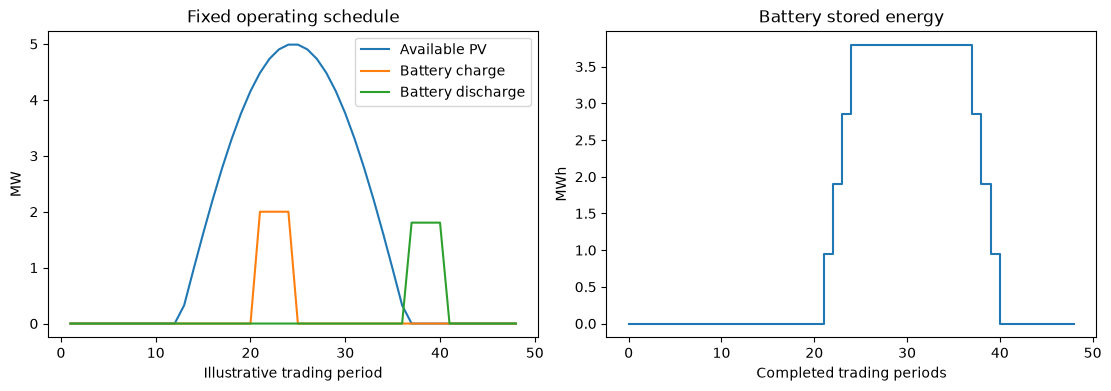

Schedule checks passed. This preview is not a grid solve.


In [6]:
preview_periods = [str(i) for i in range(1, 49)]
preview = site_schedules(SITES, default_profile(preview_periods), preview_periods)
assert net_demand_effect(10, 3, 2, 0) == (9, 3, 0)  # PV reduces load; charging adds it.
assert net_demand_effect(10, 3, 0, 2) == (5, 3, 0)  # Discharging also reduces load.
assert net_demand_effect(1, 5, 0, 0) == (0, 1, 4)  # Record surplus PV as curtailed.
for _, site in preview.groupby("node", sort=False):
    charged = (site["charge_mw"] * site["duration_hours"]).sum()
    discharged = (site["discharge_mw"] * site["duration_hours"]).sum()
    assert math.isclose(
        discharged, charged * CHARGE_EFFICIENCY * DISCHARGE_EFFICIENCY, abs_tol=1e-8
    )
first = preview[preview["node"] == SITES[0]["node"]]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
x = np.arange(1, 49)
axes[0].plot(x, first["pv_available_mw"], label="Available PV")
axes[0].plot(x, first["charge_mw"], label="Battery charge")
axes[0].plot(x, first["discharge_mw"], label="Battery discharge")
axes[0].set(
    xlabel="Illustrative trading period", ylabel="MW", title="Fixed operating schedule"
)
axes[0].legend()
axes[1].step(np.arange(49), [0, *first["stored_energy_mwh"]], where="post")
axes[1].set(
    xlabel="Completed trading periods", ylabel="MWh", title="Battery stored energy"
)
plt.show()
print("Schedule checks passed. This preview is not a grid solve.")

## Run the entire grid and download both solutions

With a GDX path and valid node IDs, this cell performs the complete study. All
model-building and reporting code is above; no repository checkout or other
notebook is required. A baseline and scenario can take substantial time and memory.

The ZIP includes `baseline/` and `pv-battery/`, each with all twelve reports and
its manifest. It also includes the schedule, per-case PV curtailment and battery
effects, audited overrides, hashed scenario definition, and comparison CSVs.
Inspect shortages, violations, and price changes before drawing conclusions.
The comparisons are per case; do not sum them as daily savings because multiple
pricing cases can represent the same period. This template does not calculate
investment returns or asset revenue.


In [7]:
study = None
if INPUT_GDX.strip():
    study = run_grid_study(INPUT_GDX, SITES, PROFILE_CSV)
    display(study["summary"].head(20))
    display(study["site_prices"].head(20))
    print("Full baseline + battery/PV solution:", study["solution_file"])
    display(
        FileLink(
            str(study["solution_file"]),
            result_html_prefix="Download the full grid study: ",
        )
    )
else:
    print("NOT RUN: set INPUT_GDX and your SITES node IDs, then run all cells.")

NOT RUN: set INPUT_GDX and your SITES node IDs, then run all cells.


## Change the study

For PV only, set `battery_mw` and `battery_mwh` to zero. For battery only, set
`pv_mw` to zero. Copy a site row to study another node, or provide a measured PV
profile and a different feasible battery schedule in `PROFILE_CSV`. Keep each
scenario ZIP to compare locations and capacities. The source GDX is unchanged.

The supplied profile is illustrative and battery dispatch is predetermined.
PV curtailment can differ between pricing cases because their original demands
differ. These assets appear in `site-effects.csv`; the ordinary generator report
continues to describe the source grid's offers. Review configuration paths and
input-data permissions before sharing the archive.
